# Titanic Exercise

to install seaborn :
```bash
conda install -c conda-forge seaborn
````


In [1]:
import pandas as pd
from seaborn import load_dataset
import matplotlib.pyplot as plt
import numpy as np

In [15]:
embarked_labels = {
  "C": "Cherbourg",
  "Q": "Queenstown",
  "S": "Southampton",
}

In [16]:
# 1. Load the dataset
titanic = load_dataset("titanic")
titanic


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [17]:
titanic.info()
titanic.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# 2. Data cleaning
# 2.1. Check the missing values
print(titanic.shape)
print(titanic.isnull().sum())

# 2.2. Replace the missing values in age with the mean
titanic["age"].fillna(titanic["age"].mean(), inplace=True)

# 2.3 rop unused columns
# titanic.drop("deck", axis=1, inplace=True)
# titanic.drop(columns=["deck", "who", "embark_town", "class", "alive"], inplace=True)

# 2.4 drop the rows with missing values in embarked
titanic.dropna(subset=["embarked"], inplace=True)

# 2.5 Transform month age to 1 year
titanic.age = titanic.age.map(lambda age: 1 if age < 1 else age)
titanic.shape

(889, 10)
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
alone         0
dtype: int64


/var/folders/9m/mdxclk9x25z0_ny0wr9rt4n80000gn/T/ipykernel_7300/4093553467.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["age"].fillna(titanic["age"].mean(), inplace=True)


(889, 10)

In [19]:
titanic.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
alone         0
dtype: int64

In [ ]:
# 3 Analyse data
# 3.1 Calculer le taux global de survie des passagers du Titanic.

# titanic.loc[titanic.survived == 1].survived.count() / titanic.survived.count()
# titanic.survived.sum() / titanic.survived.count()
# titanic.survived.mean()
titanic.survived.value_counts() / titanic.shape[0]

survived
0    0.617548
1    0.382452
Name: count, dtype: float64

In [99]:
# 3.2 Analyser la répartition des passagers par classe (Pclass) et par port d'embarquement (Embarked).

# pd.crosstab(titanic.pclass, titanic.embarked)
titanic.groupby(["embarked"]).pclass.value_counts(normalize=True).unstack()
# titanic.groupby(["embarked", "pclass"]).survived.count().reset_index().pivot(index="embarked", columns="pclass", values="survived")

pclass,1,2,3
embarked,,,
C,0.505952,0.101190,0.392857
Q,0.025974,0.038961,0.935065
S,0.197205,0.254658,0.548137


In [50]:
# 3.3 Calculer la proportion de passagers masculins et féminins.
titanic["sex"].value_counts(normalize=True)

sex
male      0.649044
female    0.350956
Name: proportion, dtype: float64

In [62]:
# 3.4 Identifier la distribution d'âge des passagers et trouver les catégories d'âge les plus représentées. (look pd.cut() function with bins)

# titanic.age.value_counts().sort_index().plot()

labels=["child", "teen", "young adult", "adult", "senior"]
bins=[0, 12, 18, 30, 65, 100]
titanic["age_category"] = pd.cut(titanic.age, bins=bins, labels=labels, right=False)
display(titanic)
titanic.age_category.value_counts()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone,age_category
0,0,3,male,22.000000,1,0,7.2500,S,True,False,young adult
1,1,1,female,38.000000,1,0,71.2833,C,False,False,adult
2,1,3,female,26.000000,0,0,7.9250,S,False,True,young adult
3,1,1,female,35.000000,1,0,53.1000,S,False,False,adult
4,0,3,male,35.000000,0,0,8.0500,S,True,True,adult
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,True,True,young adult
887,1,1,female,19.000000,0,0,30.0000,S,False,True,young adult
888,0,3,female,29.699118,1,2,23.4500,S,False,False,young adult
889,1,1,male,26.000000,0,0,30.0000,C,True,True,young adult


age_category
young adult    448
adult          317
child           68
teen            45
senior          11
Name: count, dtype: int64

<Axes: xlabel='age_category'>

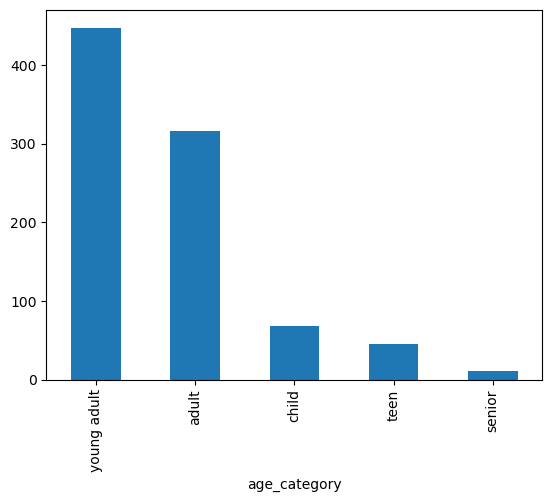

In [66]:
titanic.age_category.value_counts().plot.bar()

<Axes: xlabel='pclass'>

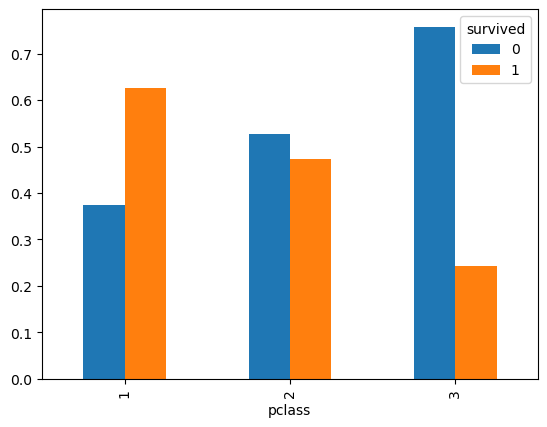

In [73]:
# 4 Alives analyse
# 4.1 Analyser la survie en fonction de la classe des billets (Pclass)
# titanic.groupby("pclass").survived.mean()
titanic.groupby("pclass").survived.value_counts(normalize=True).unstack().plot.bar()


<Axes: xlabel='sex'>

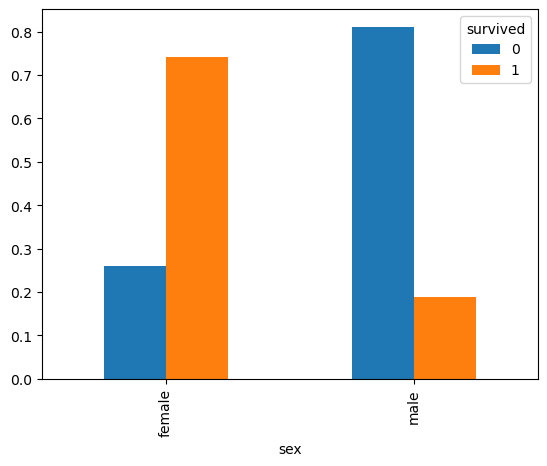

In [79]:
# 4.2 Examiner la survie en fonction du genre (Sex) des passagers.
titanic.groupby("sex").survived.mean()
titanic.groupby("sex").survived.value_counts(normalize=True).unstack().plot.bar()

<Axes: xlabel='pclass,sex'>

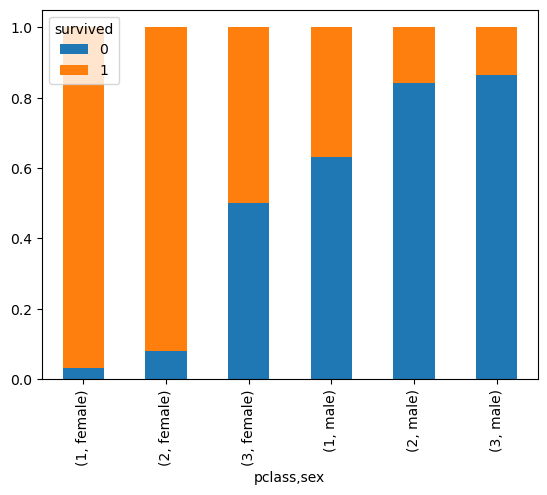

In [91]:
titanic.groupby(["pclass", "sex"]).survived\
  .value_counts(normalize=True).unstack()\
  .sort_index(level=[1], ascending=True)\
  .plot.bar(stacked=True)

In [94]:
# 4.3 Étudier la survie en fonction de l'âge (Age) des passagers.

titanic.groupby("age_category").survived.mean()

/var/folders/9m/mdxclk9x25z0_ny0wr9rt4n80000gn/T/ipykernel_7300/2035095791.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby("age_category").survived.mean()


age_category
child          0.573529
teen           0.488889
young adult    0.328125
adult          0.413249
senior         0.090909
Name: survived, dtype: float64

In [105]:
df = titanic.groupby(["age_category", "sex", "pclass"]).survived
display(df.value_counts().unstack())
df.mean().unstack()

/var/folders/9m/mdxclk9x25z0_ny0wr9rt4n80000gn/T/ipykernel_7300/3310721298.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = titanic.groupby(["age_category", "sex", "pclass"]).survived


survived                      0   1
age_category sex    pclass         
child        female 1         1   0
                    2         0   8
                    3        12  11
             male   1         0   3
                    2         0   9
                    3        16   8
teen         female 1         0   7
                    2         0   4
                    3         4   8
             male   1         0   1
                    2         2   0
                    3        17   2
young adult  female 1         1  30
                    2         3  28
                    3        38  45
             male   1        28  14
                    2        42   3
                    3       189  27
adult        female 1         1  52
                    2         3  30
                    3        18   8
             male   1        44  26
                    2        45   5
                    3        75  10
senior       female 1         0   0
                    2         0   0
                    3         0   0
             male   1         5   1
                    2         2   0
                    3         3   0

pclass                      1         2         3
age_category sex                                 
child        female  0.000000  1.000000  0.478261
             male    1.000000  1.000000  0.333333
teen         female  1.000000  1.000000  0.666667
             male    1.000000  0.000000  0.105263
young adult  female  0.967742  0.903226  0.542169
             male    0.333333  0.066667  0.125000
adult        female  0.981132  0.909091  0.307692
             male    0.371429  0.100000  0.117647
senior       female       NaN       NaN       NaN
             male    0.166667  0.000000  0.000000

In [98]:
# 4.4 Analyser la survie en fonction du port d'embarquement (Embarked).
titanic.groupby("embarked").survived.mean()

embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64

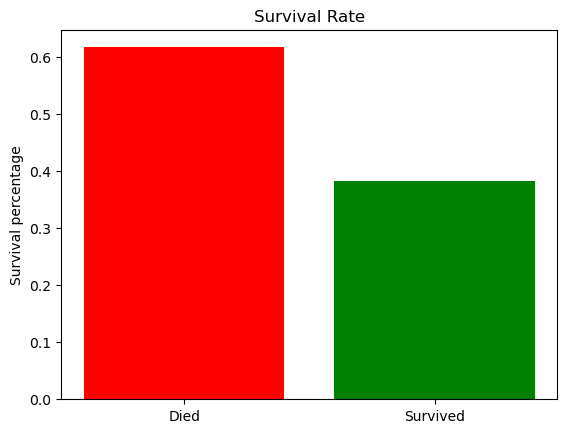

In [ ]:
# 5 Plottings
# 5.1 Créer un diagramme à barres (plt.bar) pour visualiser le taux de survie global.

survival_rate = titanic.survived.value_counts(normalize=True)

plt.bar(["Died", "Survived"], survival_rate.values, color=["r", "g"])
plt.title("Survival Rate")
plt.ylabel("Survival percentage")

plt.show()


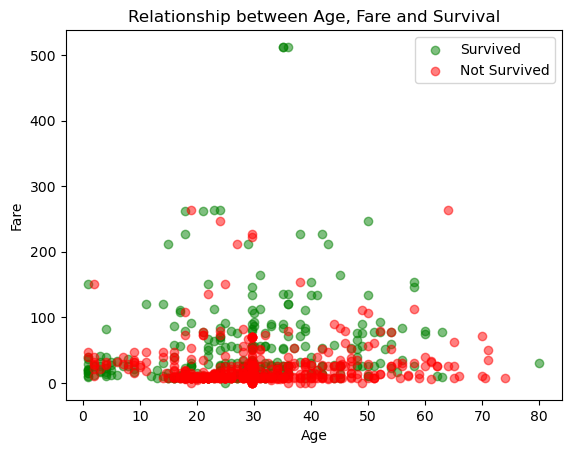

In [115]:
# 5.2 Créer un nuage de points (plt.scatter) pour représenter la relation entre l'âge (Age) et le prix du billet (Fare) en fonction de la survie.
dieds = titanic.loc[titanic.survived == 0]
alives = titanic.loc[titanic.survived == 1]

plt.scatter(
  alives.age, alives.fare,
  c="g", label="Survived", alpha=0.5
)
plt.scatter(
  dieds.age, dieds.fare,
  c="r", label="Not Survived", alpha=0.5
)

plt.title("Relationship between Age, Fare and Survival")
plt.legend()
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

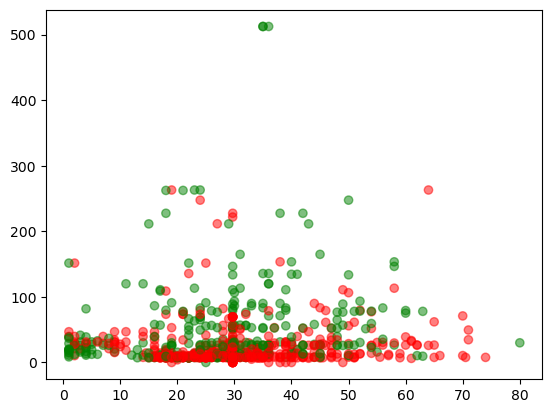

In [131]:
plt.scatter(
  titanic.age, titanic.fare, 
  c=titanic.survived.map(lambda s: "r" if s==0 else "g"),
  alpha=0.5)

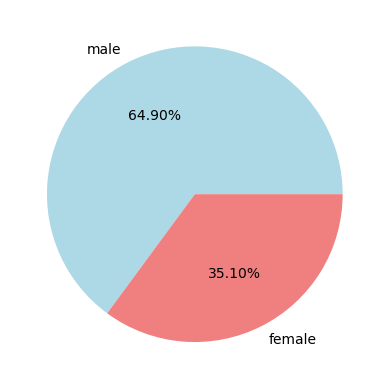

In [135]:
# 5.3 Produire un diagramme circulaire (Pie chart) pour montrer la proportion de passagers masculins et féminins
gender_proportion = titanic.sex.value_counts()
plt.pie(gender_proportion, labels=gender_proportion.index, autopct="%.2f%%", colors=("lightblue", "lightcoral"))
plt.show()

embarked,C,Q,S
pclass,,,
1,85,2,127
2,17,3,164
3,66,72,353


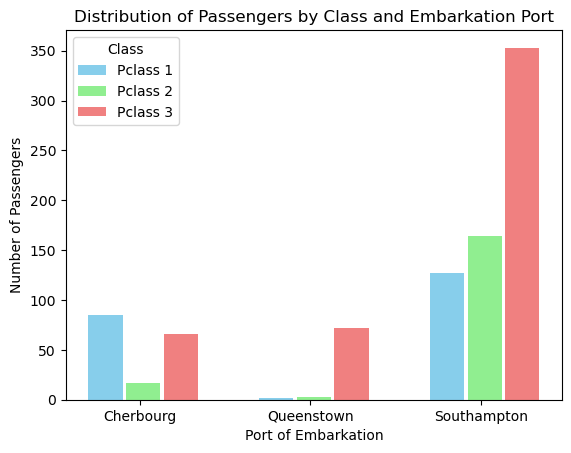

In [142]:
# 5.4 Générer un graphique en barres (plt.bar) pour montrer la répartition des passagers par classe (Pclass) et par port d'embarquement (Embarked).

distribution_by_class_embarked = titanic.groupby(['pclass', 'embarked']).size().unstack()
display(distribution_by_class_embarked)

fig, ax = plt.subplots()
width = 0.2
class_labels: list[str] = distribution_by_class_embarked.columns.map(embarked_labels.get)
enu: list[tuple[int, tuple[int, str]]] = enumerate(zip(distribution_by_class_embarked.index, ["skyblue", "lightgreen", "lightcoral"]))
for i, (pclass, color) in enu:
  positions: list[int|float] = list(range(len(class_labels))) if i==0 else [pos + width + 0.02 for pos in positions]
  plt.bar(positions, distribution_by_class_embarked.loc[pclass], width=width, label=f'Pclass {pclass}', color=color)

# Adding labels and title
plt.title('Distribution of Passengers by Class and Embarkation Port')
plt.xlabel('Port of Embarkation')
plt.ylabel('Number of Passengers')
plt.xticks([pos + width for pos in range(len(class_labels))], class_labels)
plt.legend(title='Class')

# Show the plot
plt.show()

([<matplotlib.axis.XTick at 0x310de5070>,
 [Text(0, 0, 'Cherbourg'),
  Text(1, 0, 'Queenstown'),
  Text(2, 0, 'Southampton')])

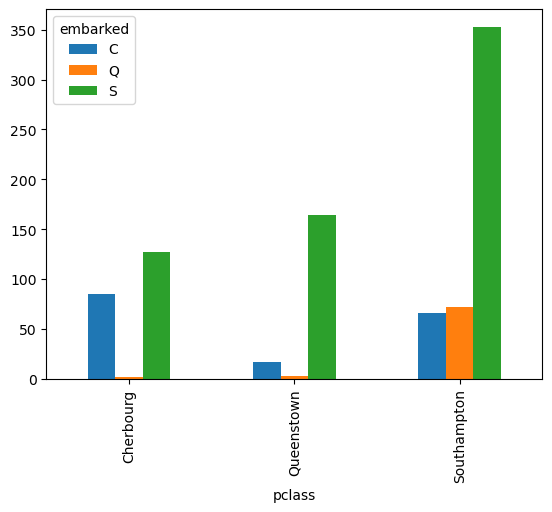

In [144]:
distribution_by_class_embarked.plot.bar()
plt.xticks(list(range(len(distribution_by_class_embarked.index))), labels=class_labels)

,age,fare,pclass,sibsp,parch,gender,survived
age,1.000000,0.088602,0.328025,0.231908,0.178146,0.089491,0.074497
fare,0.088602,1.000000,0.548193,0.160887,0.217532,0.179958,0.255290
pclass,0.328025,0.548193,1.000000,0.081656,0.016824,0.127741,0.335549
sibsp,0.231908,0.160887,0.081656,1.000000,0.414542,0.116348,0.034040
parch,0.178146,0.217532,0.016824,0.414542,1.000000,0.247508,0.083151
gender,0.089491,0.179958,0.127741,0.116348,0.247508,1.000000,0.541585
survived,0.074497,0.255290,0.335549,0.034040,0.083151,0.541585,1.000000


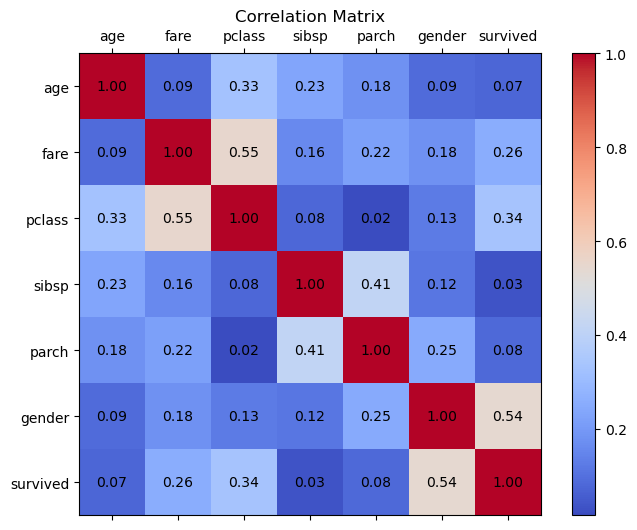

In [158]:
import numpy as np
# 6 Bonus for the datascients experts ;P
# Examiner la corrélation entre les différentes caractéristiques des passagers pour identifier les relations significatives.
correlation_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'gender', 'survived']
titanic["gender"] = titanic.sex.map({"male": 0, "female": 1})

correlation_matrix = (titanic[correlation_columns].corr()**2)**(1/2)
display(correlation_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(correlation_matrix, cmap="coolwarm")
fig.colorbar(cax)

# set labels
ax.set_xticks(list(range(len(correlation_columns))))
ax.set_yticks(list(range(len(correlation_columns))))
ax.set_xticklabels(correlation_columns)
ax.set_yticklabels(correlation_columns)

# Display correlation coefficient
for i in range(len(correlation_columns)):
  for j in range(len(correlation_columns)):
    text = ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")
  
plt.title("Correlation Matrix")

plt.show()

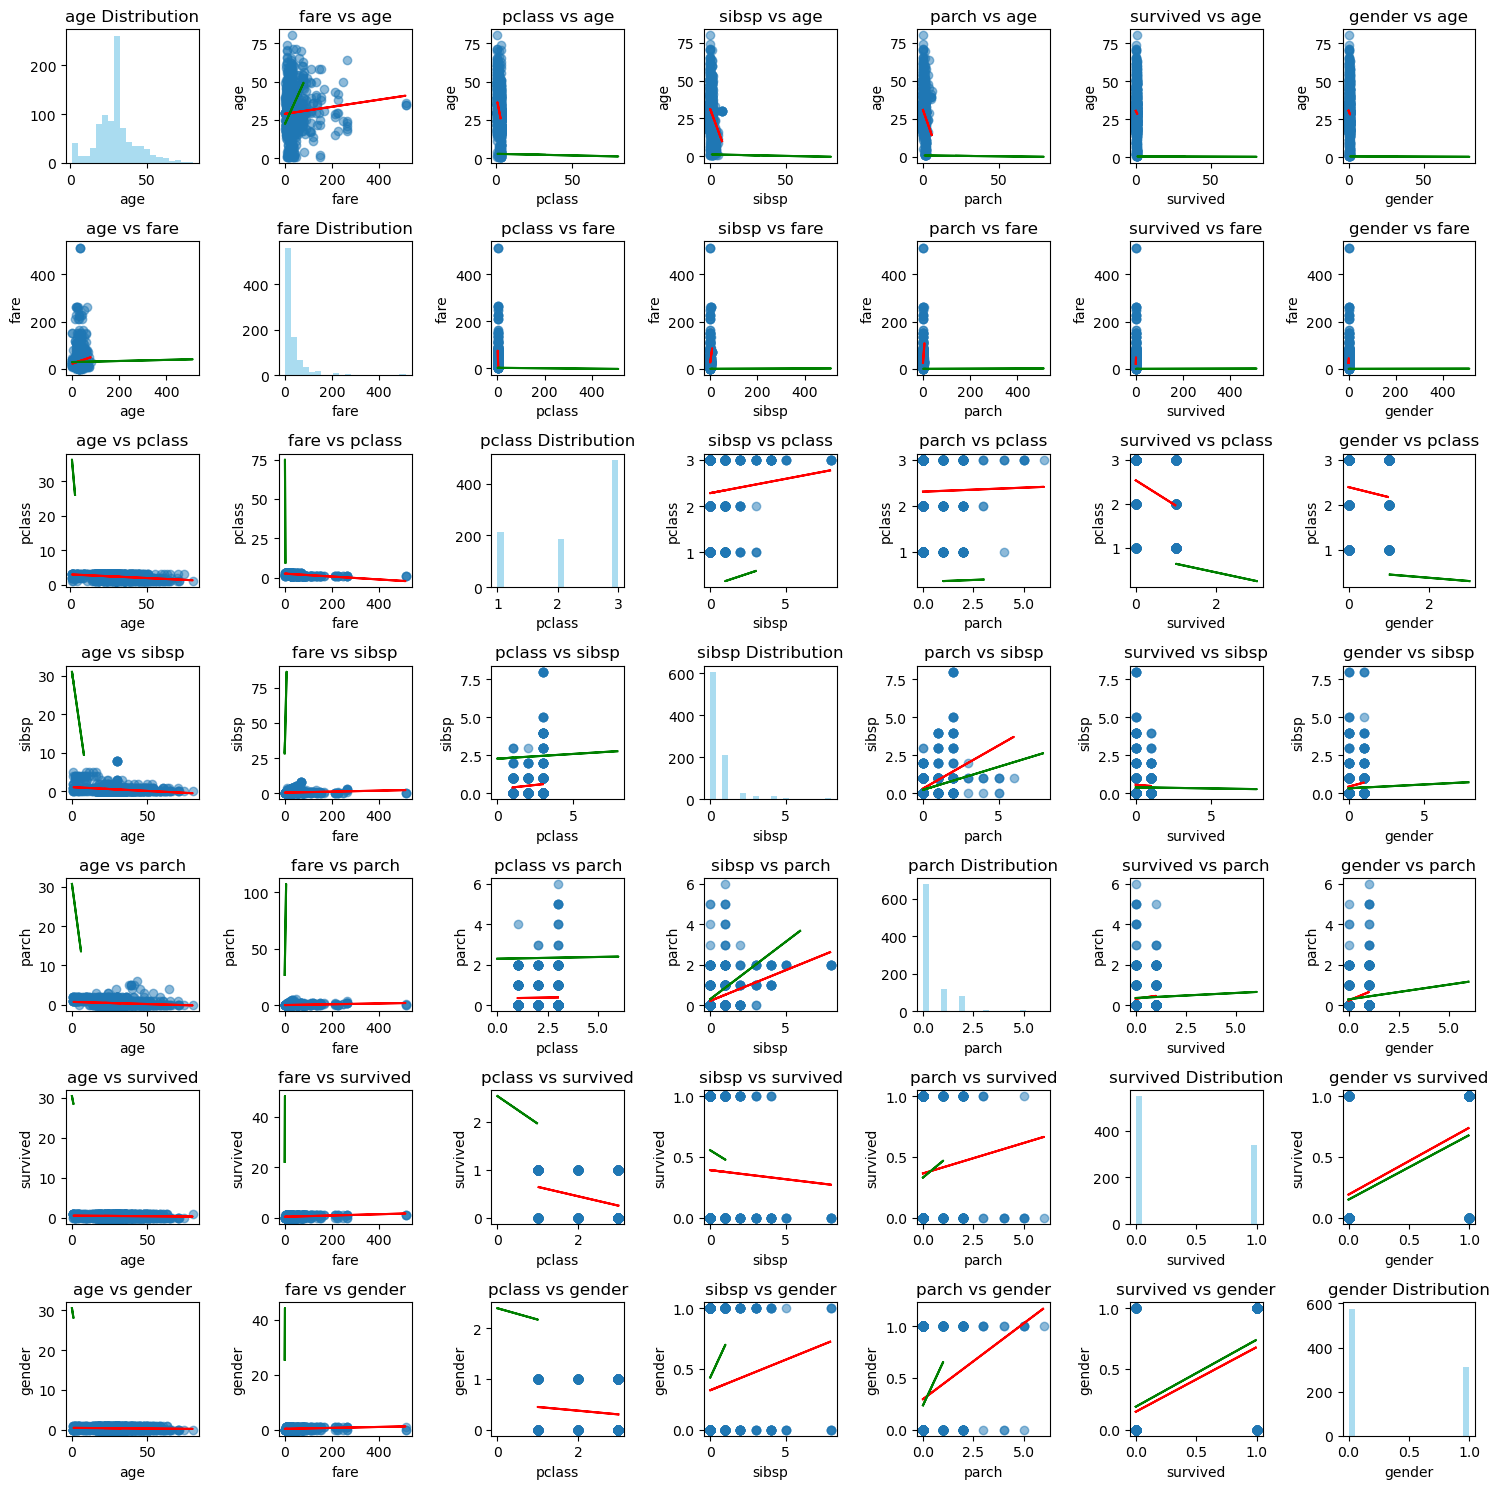

In [160]:
import numpy as np

# Select relevant numerical columns
numerical_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived', 'gender']

# Create a matrix of scatter plots
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=len(numerical_columns), figsize=(15, 15))

for i in range(len(numerical_columns)):
    for j in range(len(numerical_columns)):
        if i == j:
            axes[i, j].hist(titanic[numerical_columns[i]], bins=20, color='skyblue', alpha=0.7)
            axes[i, j].set_title(f'{numerical_columns[i]} Distribution')
            axes[i, j].set_xlabel(numerical_columns[i])
        else:
            axes[i, j].scatter(titanic[numerical_columns[j]], titanic[numerical_columns[i]], alpha=0.5)
            axes[i, j].set_title(f'{numerical_columns[j]} vs {numerical_columns[i]}')
            axes[i, j].set_xlabel(numerical_columns[j])
            axes[i, j].set_ylabel(numerical_columns[i])
            a, b = np.polyfit(titanic[numerical_columns[j]], titanic[numerical_columns[i]], 1)
            axes[i, j].plot(titanic[numerical_columns[j]], a*titanic[numerical_columns[j]]+b, c="r")
            a, b = np.polyfit(titanic[numerical_columns[i]], titanic[numerical_columns[j]], 1)
            axes[i, j].plot(titanic[numerical_columns[i]], a*titanic[numerical_columns[i]]+b, c="g")

# Adjust layout
plt.tight_layout()
plt.show()